# SynBIC Bioinformatics Seminar: Introduction to PCA, Clustering and Data Analysis, Part 1

___

#### Overview and Motivation

Principal Component Analysis (PCA) has become one of the most widely used tools for exploring biological data. In many experiments, we measure large numbers of variables at once, such as genes, proteins, metabolites, or image-derived features. PCA helps us make sense of these datasets by identifying the main directions along which the data vary.

Rather than focusing only on the raw values of individual variables, PCA is a linear transform aimed to study the structure of variance across the dataset. This makes it useful for dimensionality reduction, visualising complex datasets, identifying dominant features, and supporting clustering or other downstream analyses. Applications of PCA and related methods are common across biology, including transcriptomics, microscopy, and other high-dimensional measurements.

The aim of this workshop is to give you an intuitive feel for PCA and some common downstream analyses. While a few simple equations may be introduced for clarity, a detailed mathematical treatment is beyond the scope of this session. If you would like a deeper mathematical introduction, I recommend [A Tutorial on Principal Component Analysis](https://arxiv.org/abs/1404.1100) as future read.

Finally, this seminar is designed to support self-paced learning. Although it is accompanied by a live presentation, feel free to move through the material at a pace that suits your own level of confidence and experience.


___

#### Summary of this notebook
- Introduction to PCA.
- Preprocessing data before transforming with PCA.
- Cumulative variance explained by Principal Components.
- Principal Component Loadings of original features.
- Give it a go! Combine learnt knowledge on the Breast Cancer Wisconsin Dataset from [Wolberg et al](https://www.semanticscholar.org/paper/Nuclear-feature-extraction-for-breast-tumor-Street-Wolberg/53f0fbb425bc14468eb3bf96b2e1d41ba8087f36).

In [36]:
# Imports would usually go here, but since we're focusing on functions from different libraries, they are imported in the respective sections below.

#### Loading the data
___
In this seminar, we will play with two toy datasets from the [sklearn.datasets](https://scikit-learn.org/stable/api/sklearn.datasets.html) module: (1) the iris dataset; and (2) the breast cancer dataset. We will be converting the datasets into Pandas DataFrames, which are an excellent way of organising raw data into tables. If you are ever confused about Pandas DataFrames methods, you can read the documentation [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).

In [37]:
#### Import the Iris dataset from sklearn.datasets

from sklearn.datasets import load_iris
iris_data = load_iris()

#### Convert the dataset into a pandas DataFrame

import pandas as pd
iris_df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)

display(iris_df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


This is a small and simple dataset that will serve as a first example. As you can see from the output above, this is a dataset consisting of 150 rows (**observations**) and 4 columns (**features**). For the purpose of this exercise, begin by visualising each of these features against each other:

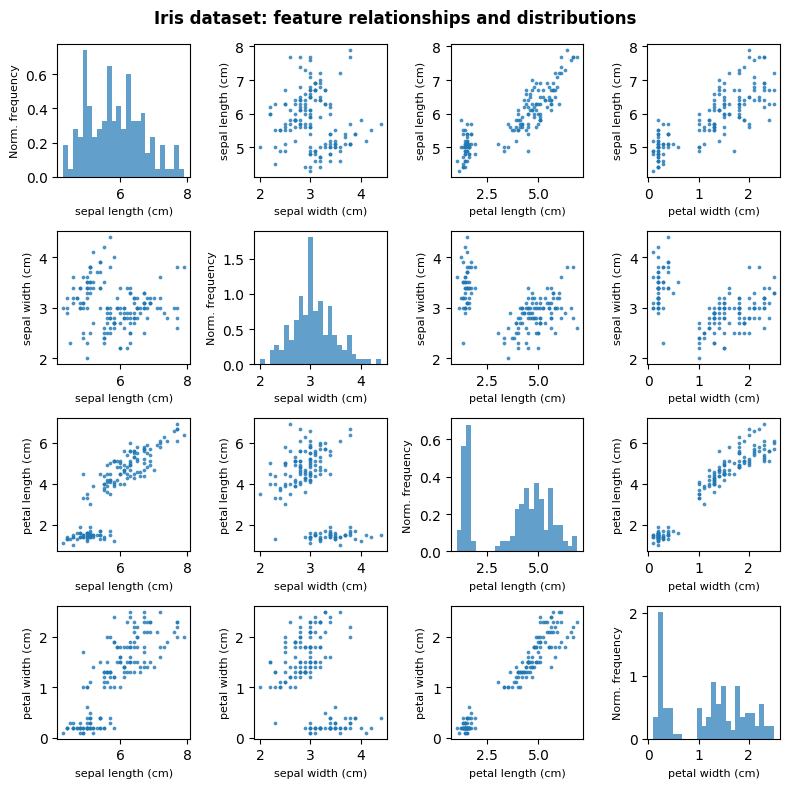

In [38]:
import matplotlib.pyplot as plt

def plot_dataset_cross_table(df):
    features = df.columns
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(8, 8))

    for i, feature_y in enumerate(features):
        for j, feature_x in enumerate(features):
            ax = axes[i, j]

            if i == j:
                ax.hist(df[feature_x], bins=25, density=True, alpha=0.7)
                ax.set_ylabel("Norm. frequency", fontsize=8)
            else:
                ax.scatter(df[feature_x], df[feature_y], s=3, alpha=0.7)
                ax.set_ylabel(feature_y, fontsize=8)

            ax.set_xlabel(feature_x, fontsize=8)

plot_dataset_cross_table(iris_df)
plt.suptitle("Iris dataset: feature relationships and distributions", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Before performing PCA, it is useful to first look carefully at the raw dataset and ask what patterns might already be present.

From inspecting the plot above, I would like you to consider:

- Do any features appear to have very different ranges or spreads?
- Are some features distributed more broadly than others?
- Do any pairs of features appear to be correlated with one another?
- Are there signs that some samples form natural groups, even before any dimensionality reduction?
- Are there any obvious outliers or unusual data points?
- Which features seem most useful for distinguishing between samples?
- If two features are strongly correlated, are they partly describing the same variation in the data?

These are important because PCA works by identifying a new set of axes (**"bases"**) which capture the most variance in the dataset. It's effectiveness and output is intrinsically tied to distributions of variance present in your raw measurements.

#### Preprocessing for PCA
___
PCA is not scale-invariant --- it will be affected by the magnitude scales of invididual features. This is obviously a problem, as some features will dominate entirely over others. For example, think of Red Blood Cell count (cells/L) vs Height (cm): the average male in the U.K. has a RBC of 4.0-5.9 x 10^12 cells/L and height of 175.9 cm. The RBC count simply from being measured at higher scales would have a greater effect on PCA algorithm relative to height. Sources: [NHS Red Blood Cell Count](https://www.nhs.uk/tests-and-treatments/red-blood-count/); [NHS Health Survey for England 2021, part 1](https://digital.nhs.uk/data-and-information/publications/statistical/health-survey-for-england/2021/part-4-trends).

Consequently we use the StandardScaler interpretation, which normalises the data to have: (1) mean=0; and (2) standard deviation=1 across features. Consequently your data features become unitless.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

#### Normalise the data
normaliser = StandardScaler()  # **very important** step --- see explanation above
scaled_data = normaliser.fit_transform(iris_df) # NOTE: this returns a numpy array, not a pandas DataFrame. We will convert it back to a DataFrame in the next step.
scaled_df = pd.DataFrame(scaled_data, columns=iris_df.columns)

#### Try and apply the instance method df.describe() to see how the data's distribution changes before and after transformation.
#iris_df.describe()
#scaled_df.describe()

# Do keep in mind, minor floating-point differences are normal.

#### Performing PCA on the data
___

Now we will apply the PCA method to our data. 

Simplest way to imagine what is going behind the scenes is a **rigid rotation of your coordinate system**:
- Your data lies in an n-dimensional space. We know that all coordinate axes are orthogonal to each other and pass through the ordinate.
- You are only capable of rotating all the axes at the same time around the ordinate (you cannot scale or bend the space).
- A position for PC1 (first axis) exists in which it captures the most variance across your remaining data (minimises error for a regression line).
    - A position for PC2 (second) exist in which it captures most (global maximum) of variance across your remaining data.
        - This is repeated up to N dimensions

For 2 dimensions the rotation looks like:

![PCA_illustration](figures\Principal_20Component_20Analysis_20second_20principal.gif)

Image source: https://builtin.com/data-science/step-step-explanation-principal-component-analysis


(What happens actually happens behind the scenes is that: eigenvalues of the covariance matrix for your samples and features indicate the principle directions, but that is beyond the scope of the exercise)

In [40]:
#### Perform PCA on your dataset
# Run PCA
pca = PCA()  # assign the PCA method to a variable (not necessary, but good for visualising)
iris_model = pca.fit(scaled_data)  # builds a model from the dataset
transformed_data = iris_model.transform(scaled_data)  # transforms the scaled data using the model

# Alternatively, you can do this in one step, as we did with StandardScaler above.
# However, the above method allows you to save the fitted PCA instance, which can allow you to reuse the shape.
# transformed_data = PCA().fit_transform(scaled_data)

iris_pca_df = pd.DataFrame(
    transformed_data,
    columns=[f"PC{i+1}" for i in range(transformed_data.shape[1])]
)

display(iris_pca_df)

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


PCA has now been successfully been used to project our iris data into PCA space.

#### Cumulative Variance
In PCA, the Principal Components (PCs) establish the new bases for plotting our data. These PCs are **orthogonal** (meaning they are independent from each other), and are automatically ranked in order of most captured variance. Consequently, each PC is correlated with each feature to different degrees, and the features which are responsible for the most variation in data are most strongly correlated with high-ranked PCs.

Below I show you the most fundamental ways of visualising the properties of these PCs:

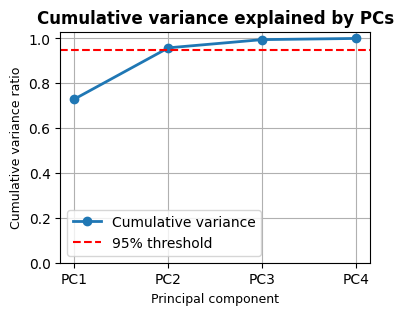

In [41]:
#### Plot the cumulative variance ratio across PCs

import numpy as np
import seaborn as sns

# This is a property of the fitted PCA model.
# Remember how I said it's convenient to save the fitted PCA instance? This is one of the reasons why.
explained_variance_ratio = iris_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(4, 3))
plt.plot(
    iris_pca_df.columns,
    cumulative_variance,
    linestyle='-',
    marker='o',
    linewidth=2,
    label='Cumulative variance'
)
plt.axhline(
    0.95,
    color='r',
    linestyle='--',
    label='95% threshold')
plt.ylabel('Cumulative variance ratio', fontsize=9)
plt.xlabel('Principal component', fontsize=9)
plt.title('Cumulative variance explained by PCs', fontsize=12, fontweight='bold')
plt.grid(True)
plt.ylim([0, 1.03])
plt.legend()
plt.show()


### Loading heatmap
A loading heatmap shows the contribution of each original dimension to the derived PC dimensions.

- A heatmap is a plot that indicates a pairwise relationship between two sets of variables - in our case, the original features and the PC axes.
    - Each cell contains the component of the unit eigenvector corresponding to that feature-PC pair.
        - This is the exact reason why both the row and column sums of squared loadings equal 1 - each PC is a unit vector (rows), and each original feature is fully decomposed across all PCs (columns).

The loading heatmap is therefore simply a matrix description of the rotation performed by PCA.

- Because the loading matrix **V** is orthonormal, its inverse is just its transpose (**V⁻¹ = Vᵀ**). This means you can recover your original dimensions from the PC scores by a simple matrix multiplication:

$$\hat{X} = Z V^\top$$

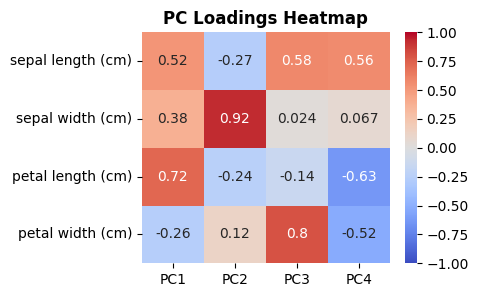

In [42]:
#### Plot heatmap of PC loading correlations with original features
plt.figure(figsize=(4, 3))
sns.heatmap(
    iris_model.components_, # Matrix of PC loadings, also retrieved from the PCA model instance.
    cmap='coolwarm',
    annot=True,
    xticklabels=iris_pca_df.columns,
    yticklabels=iris_df.columns,
    vmin =-1, vmax=1

)
plt.title('PC Loadings Heatmap', fontsize=12, fontweight='bold')
plt.show()

<details>
<summary><strong>Question:</strong> Inspect the two plots above. What do you notice about this particular dataset?</summary>

**Answer:** From the cumulative explained variance plot, we can see that **PC1 explains 73.0% of the variance** and **PC2 explains 22.9%**. Together, they explain **more than 95% of the variance** in the original data. This ability to express the data as a **linear combination** of principal components follows from the orthogonal nature of the PCA basis vectors.

In PCA, a common rule of thumb is to retain enough principal components to explain around **95% of the variance**. In this case, that means the dataset can be reduced to two dimensions while still preserving most of its structure. However, this should not be confused with a lossless procedure: some small information is still discarded. Ultimately, the decision of what to do with your PCs and which ones to keep is up to scrutiny based on the context of your original data.

From the PC loadings heatmap, we can see that **PC1** is moderately associated with **sepal length** and **sepal width**, and more strongly associated with **petal length**. **PC2** appears to be strongly associated with **sepal width**.

Hopefully, you can now appreciate why I chose the Iris dataset for this example. We can very conveniently plot in only 2 dimensions the most important PCs, and use this as an intuitive way to visualise the data by its captured variance.

</details>



Let us finally plot PC1 and PC2 so we can investigate the results of PCA graphically:

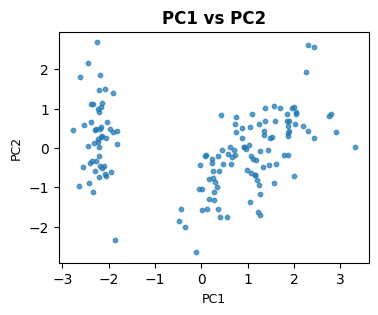

In [43]:
#### Plot PC1 vs PC2 as a scatter plot

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    s=10,
    alpha=0.7
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2', fontsize=12, fontweight='bold')
plt.show()

In [44]:
# Now try and plot PC3 vs PC4.
# Can you see any major differences from PC1 vs PC2?

The results above reflect our expectations quite nicely. Indeed, we see that our data points are visibly partitioned into two **classes** (a group of points with similar properties, e.g. a species of flower in this example). However, if we look closely at the right-most one, perhaps there might be some indication of more classes that are less obvious on first sight? Since we are working with a toy dataset, we have the luxury of knowing exactly what class each point belongs to. For your convenience, you can find the Iris Dataset right [here](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris).

This uncertainty in the number of classes one can reasonably partition raw data into leads us into the next part of this seminar, which is **clustering approaches**.

___
#### **EXTRA NOTE: On the formalism of the question and how to interpret well-separated data from a continuous response manifold**

In this dataset above, we can tell that clusters exist legitimitely from how the cells separate across PCA space. That is not always true for all datasets, and it is imperative to understand that one should never use PCA with the aims of identifying clusters. PCA fundamentally is a technique aiming to plot cells by variability, but variability can come in the form of discrete, distinct separations, or following smooth, continuous gradients, or some mixture of the two modes. Listen to the presenter to learn more about the philosophical approach to analysis in PCA.

___
#### **EXTRA TASK: THE BREAST CANCER WISCONSIN DATASET**
___

I now invite you to replicate the previous method on a toy breast cancer Wisconsin dataset from sklearn. For your convenience, I have written the first part of code for you to help you get started. For the sake of documentation, information about the dataset can be found [here](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer), but I would advise against reading it until the end of this seminar as it will spoil you the true number of classes in the dataset.

In [45]:
# Import standard libraries data organisation and plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Import PCA and standardisation tools from sklearn, and the breast cancer dataset.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer

breast_cancer_data = load_breast_cancer()
breast_cancer_df = pd.DataFrame(
    data=breast_cancer_data.data,
    columns=breast_cancer_data.feature_names
    )

# ..... now it's your turn :)